In [1]:
import superstats as sup
import pandas as pd

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


## Constants

In [2]:
NUM_STEPS = 800

## Prior

In [3]:
joint_prior = sup.JointPrior(
    v = sup.transition.Mixture(
        transitions=[
            sup.transition.RandomWalk(
                sigma=sup.Prior(dist="halfnormal", scale=0.1),
                delta=0
            ),
            sup.transition.Jump(
                proposal_prior=sup.Prior(dist="logistic", loc=0, scale=1)
            )
        ],
        mixture_weights=sup.Prior(dist="dirichlet", alpha=[20.0, 1.5]),
        bounds=(0.0, 8.0),
        initial_prior=sup.Prior(dist="normal", loc=-1.0, scale=1.0),
    ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.RandomWalk(
                sigma=sup.Prior(dist="halfnormal", scale=0.1),
                delta=0
            ),
            sup.transition.Jump(
                proposal_prior=sup.Prior(dist="logistic", loc=0, scale=1)
            )
        ],
        mixture_weights=sup.Prior(dist="dirichlet", alpha=[40.0, 1.5]),
        bounds=(0.0, 6.0),
        initial_prior=sup.Prior(dist="normal", loc=-0.5, scale=1.0),
    ),
    tau = sup.transition.RandomWalk(
        sigma=sup.Prior(dist="halfnormal", scale=0.01),
        delta=0,
        bounds=(0.0, 4.0),
        initial_prior=sup.Prior(dist="normal", loc=-2, scale=1.0)
    ),
    bias = 0.5
)

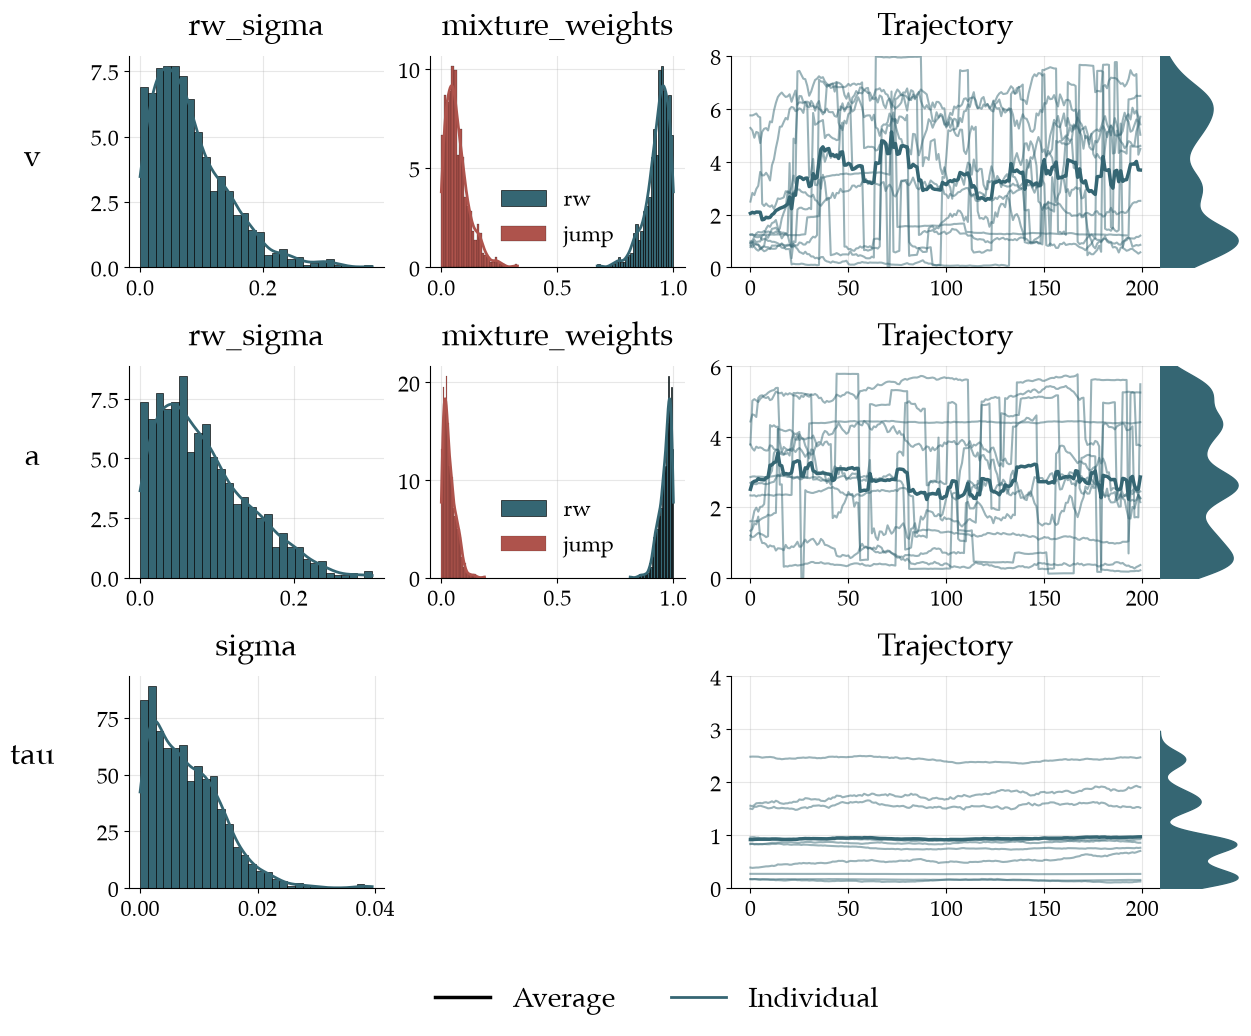

In [4]:
fig = joint_prior.plot_joint_prior(num_trajectories=10)

## Model

In [7]:
ddm = sup.simulation.sample_ddm

model = sup.Model(
    prior=joint_prior,
    simulator=ddm,
)

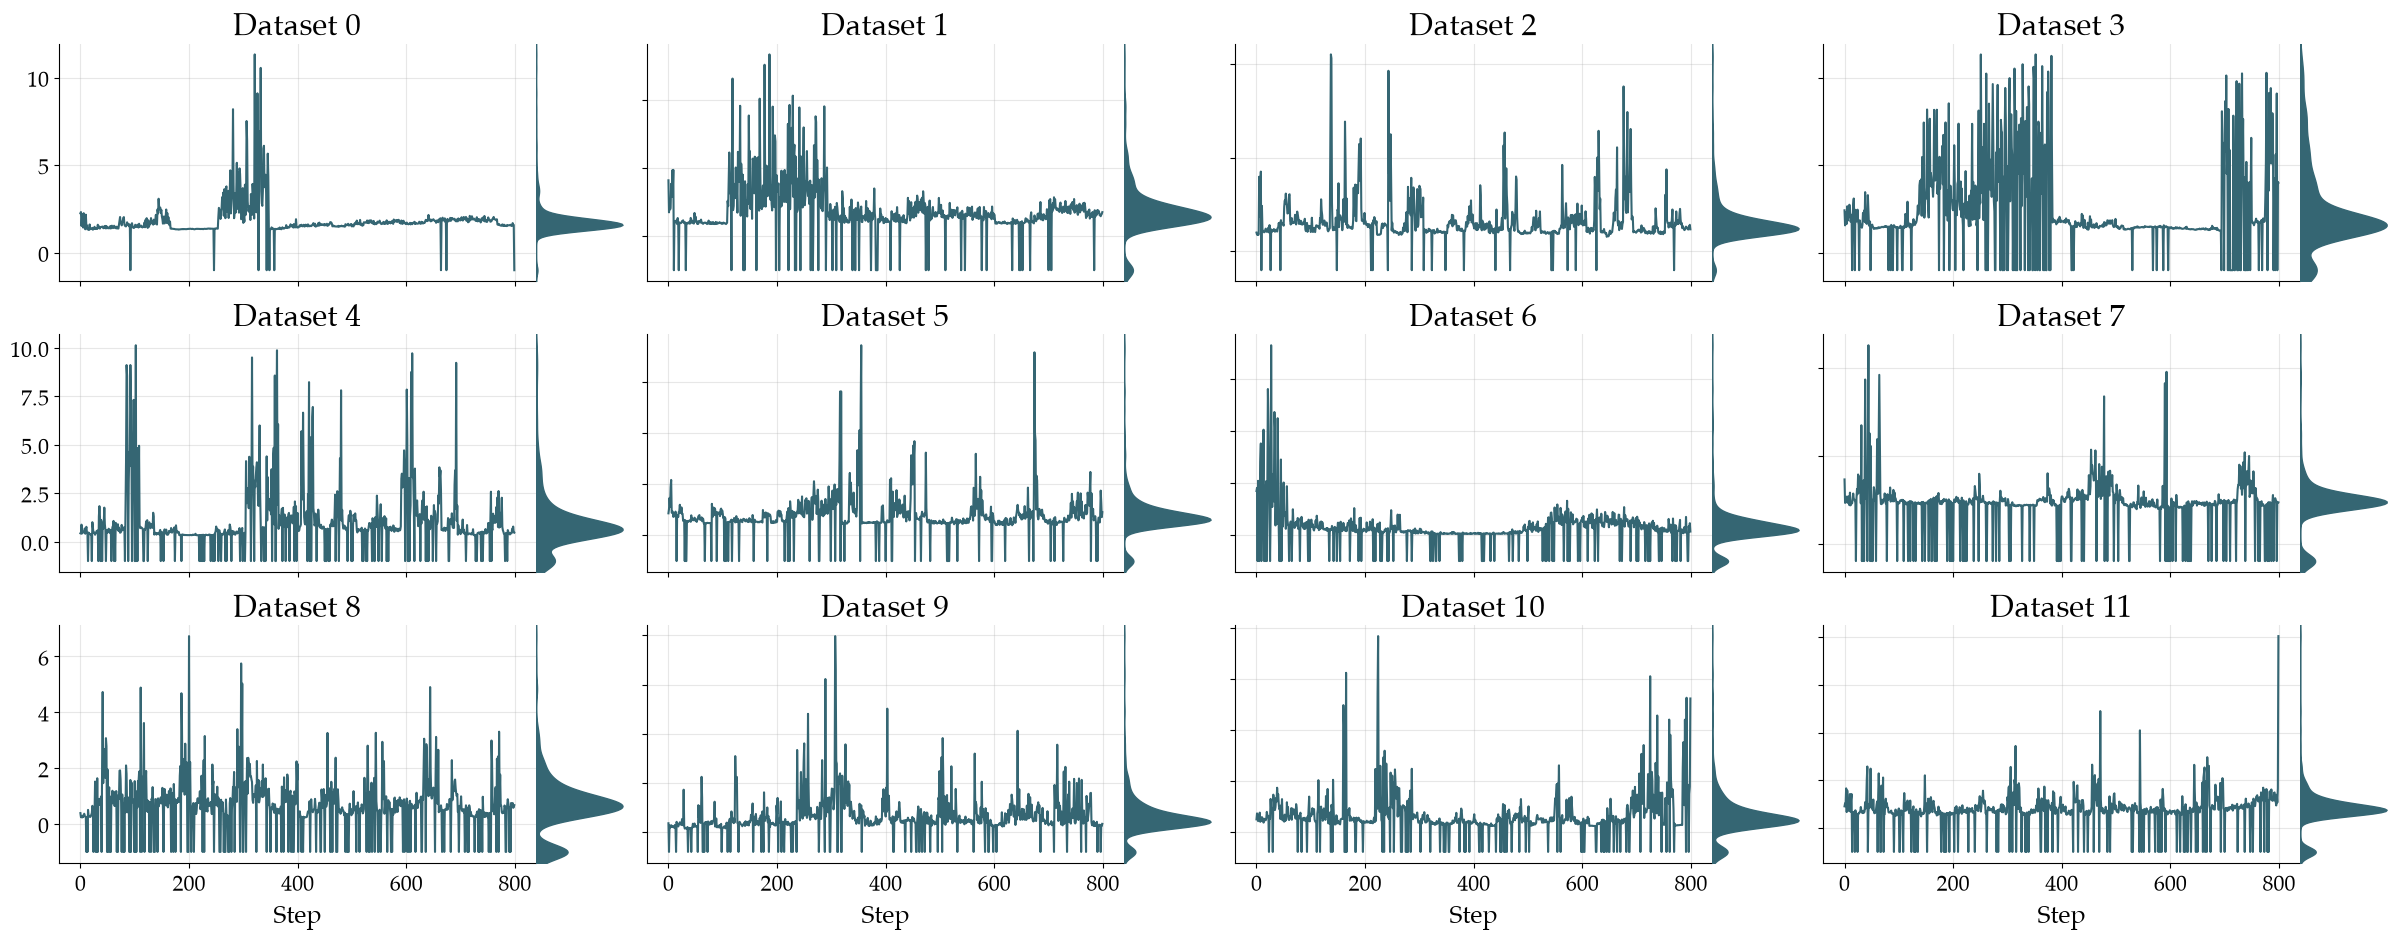

In [8]:
fig = model.plot_push_forward(
    num_sim=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="trajectory",
    num_cols=4,
)

## Workflow

In [9]:
workflow = sup.Workflow(
    model=model,
    checkpoint_filepath="checkpoints/data_application_01"
)

## Training

In [ ]:
train_data = model.sample(
    batch_size=50000,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
test_data = model.sample(
    batch_size=200,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=test_data,
    epochs=100,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 174s 104ms/step - loss: 8.4102 - val_loss: 4.6893
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 92ms/step - loss: 5.0453 - val_loss: 4.1178
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 92ms/step - loss: 4.4280 - val_loss: 3.7268
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - loss: 4.0668 - val_loss: 3.3004
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 92ms/step - loss: 3.7701 - val_loss: 3.0322
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 90ms/step - loss: 3.4236 - val_loss: 2.6878
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 90ms/step - loss: 3.1050 - val_loss: 2.4668
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 92ms/step - loss: 2.8328 - val_loss: 2.2415
Epoch 9/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 90ms/step - loss: 2.6945 - val_loss: 1.9803
Epoch 10/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - loss: 2.5828 - val_loss: 2.1625
Epoch 11/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 90ms/step - loss: 2.4482 - va

In [17]:
# history = workflow.fit_online(
#     num_steps=NUM_STEPS,
#     epochs=NUM_EPOCHS,
#     num_batches_per_epoch=NUM_ITER_PER_EPOCH,
#     batch_size=BATCH_SIZE
# )

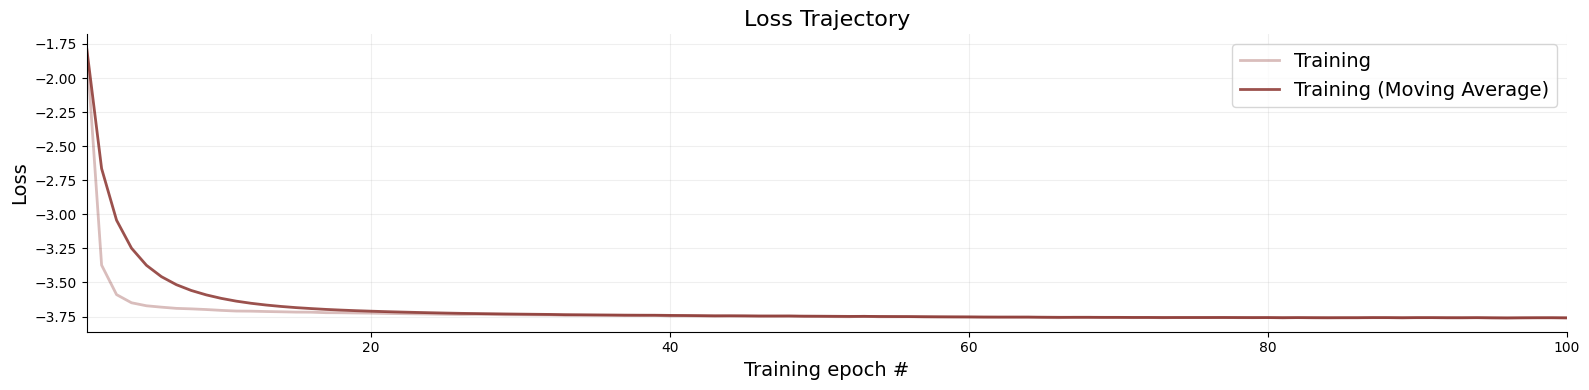

In [8]:
fig = workflow.plot_history(workflow.history)

## Verification

In [ ]:
val_data = model.sample(
    batch_size=400,
    num_steps=NUM_STEPS
)

In [ ]:
samples = workflow.sample(
    data=val_data,
    num_samples=NUM_SAMPLES,
    inference_batch_size=1
)

Summarizing:   0%|          | 0/400 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/400 [00:00<?, ?batch/s]

### Time-varying Parameters

/scicore/home/rieskamp/schuma0018/GitHub/superstats/examples/../superstats/diagnostics/plots/time_varying_verification.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


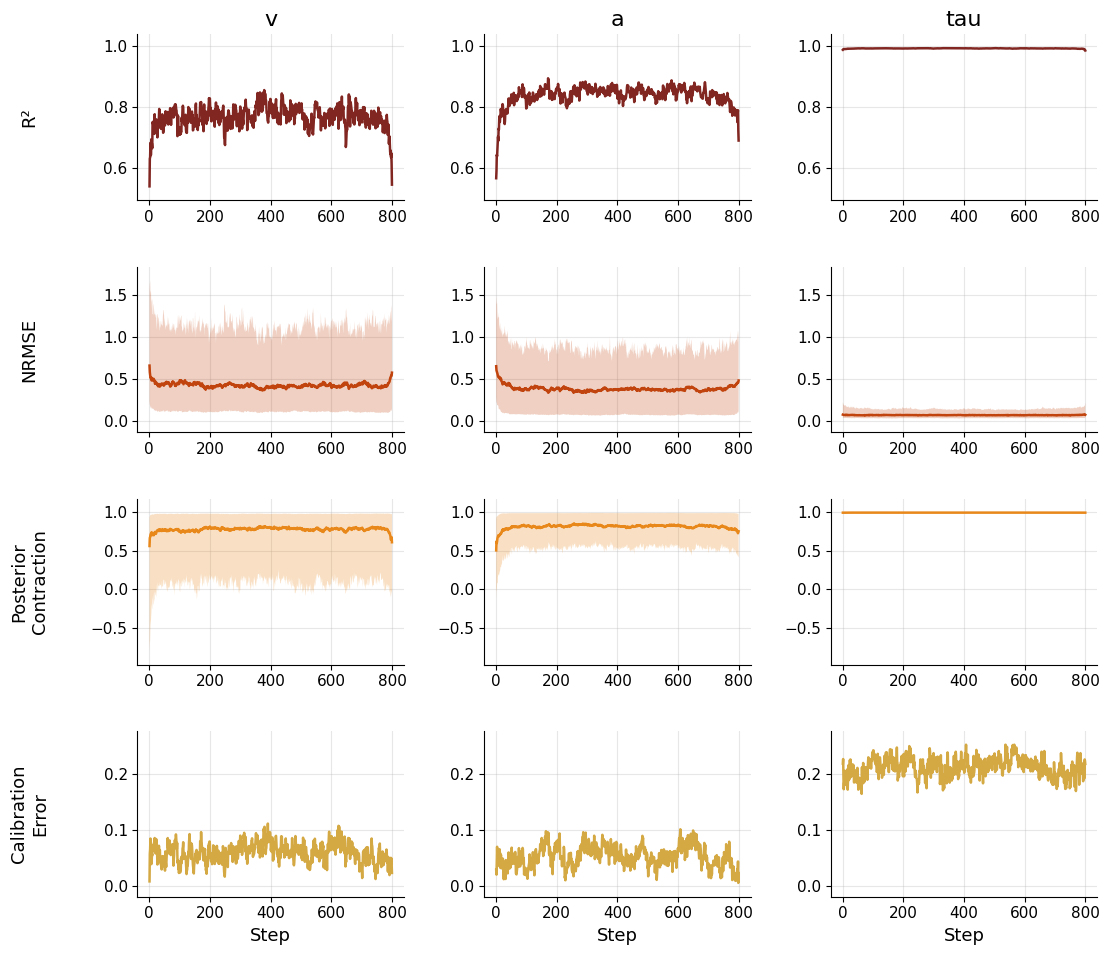

In [11]:
fig = workflow.verify_time_varying(val_data, samples)

### Time-invariant Parameters

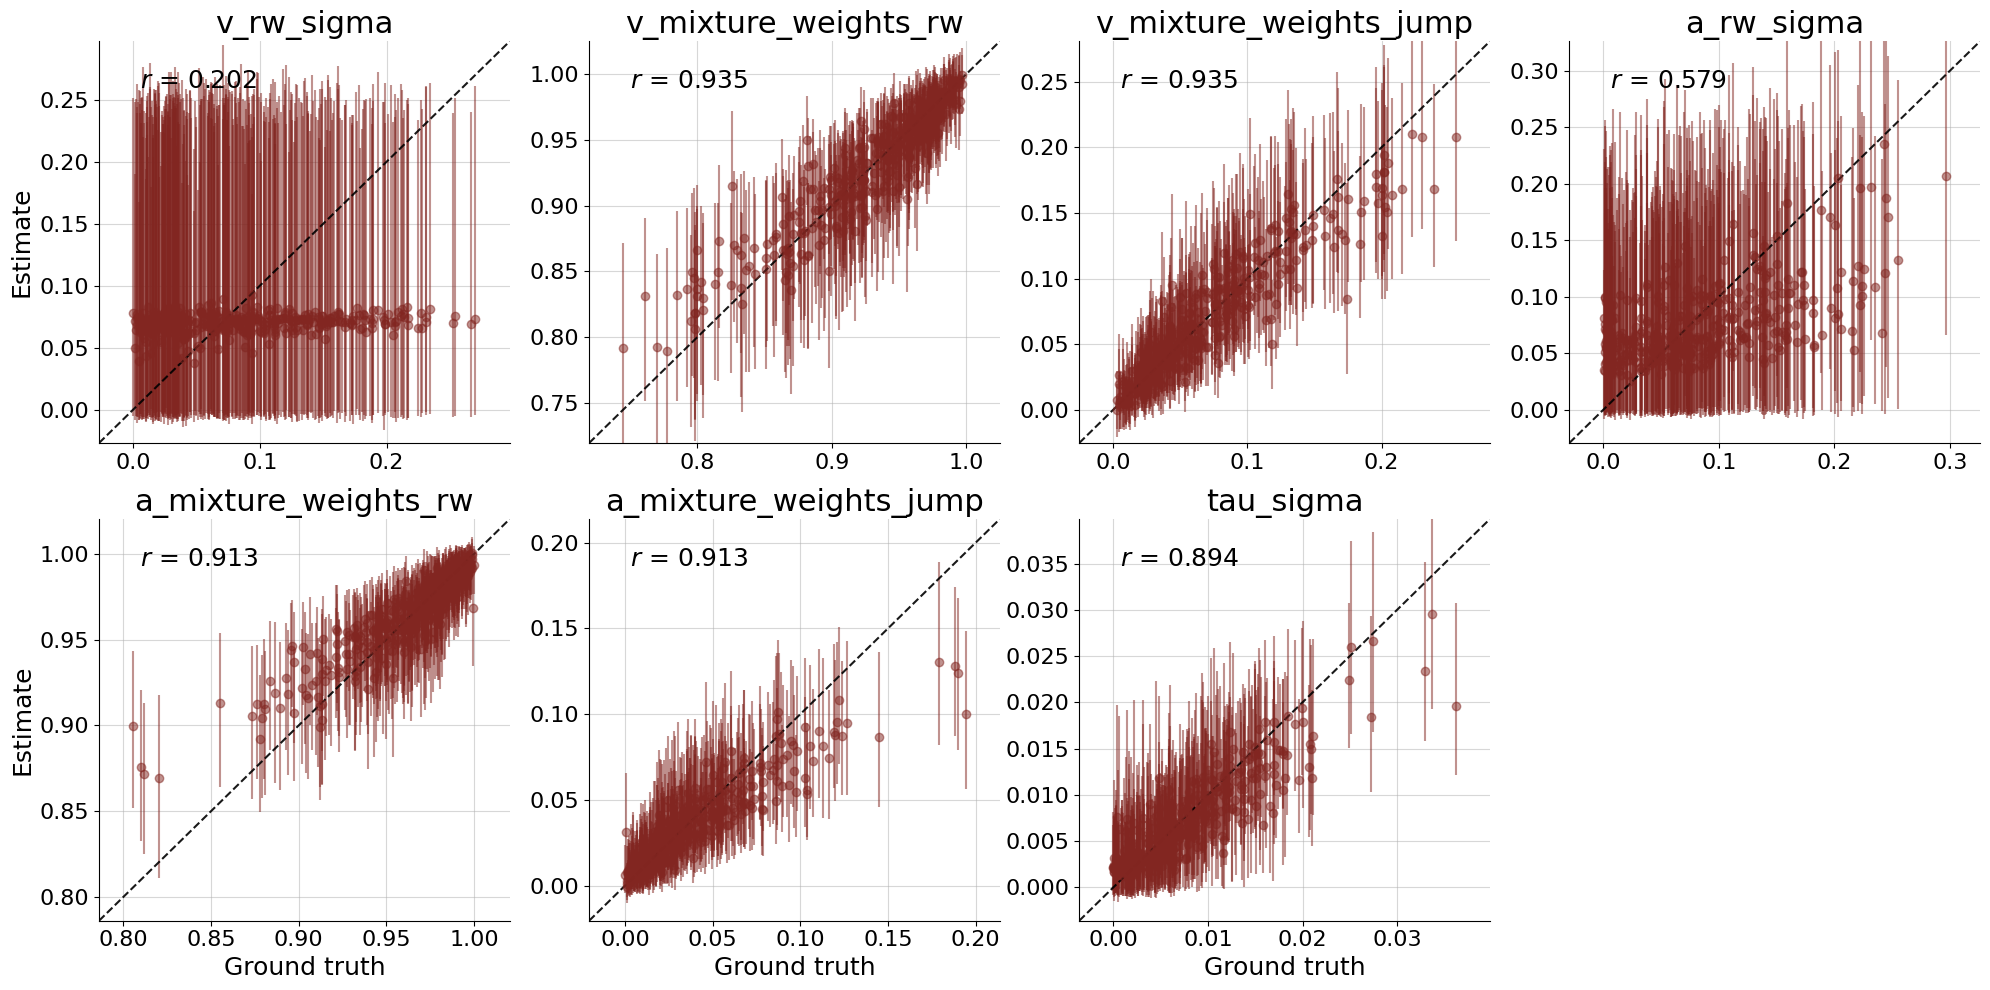

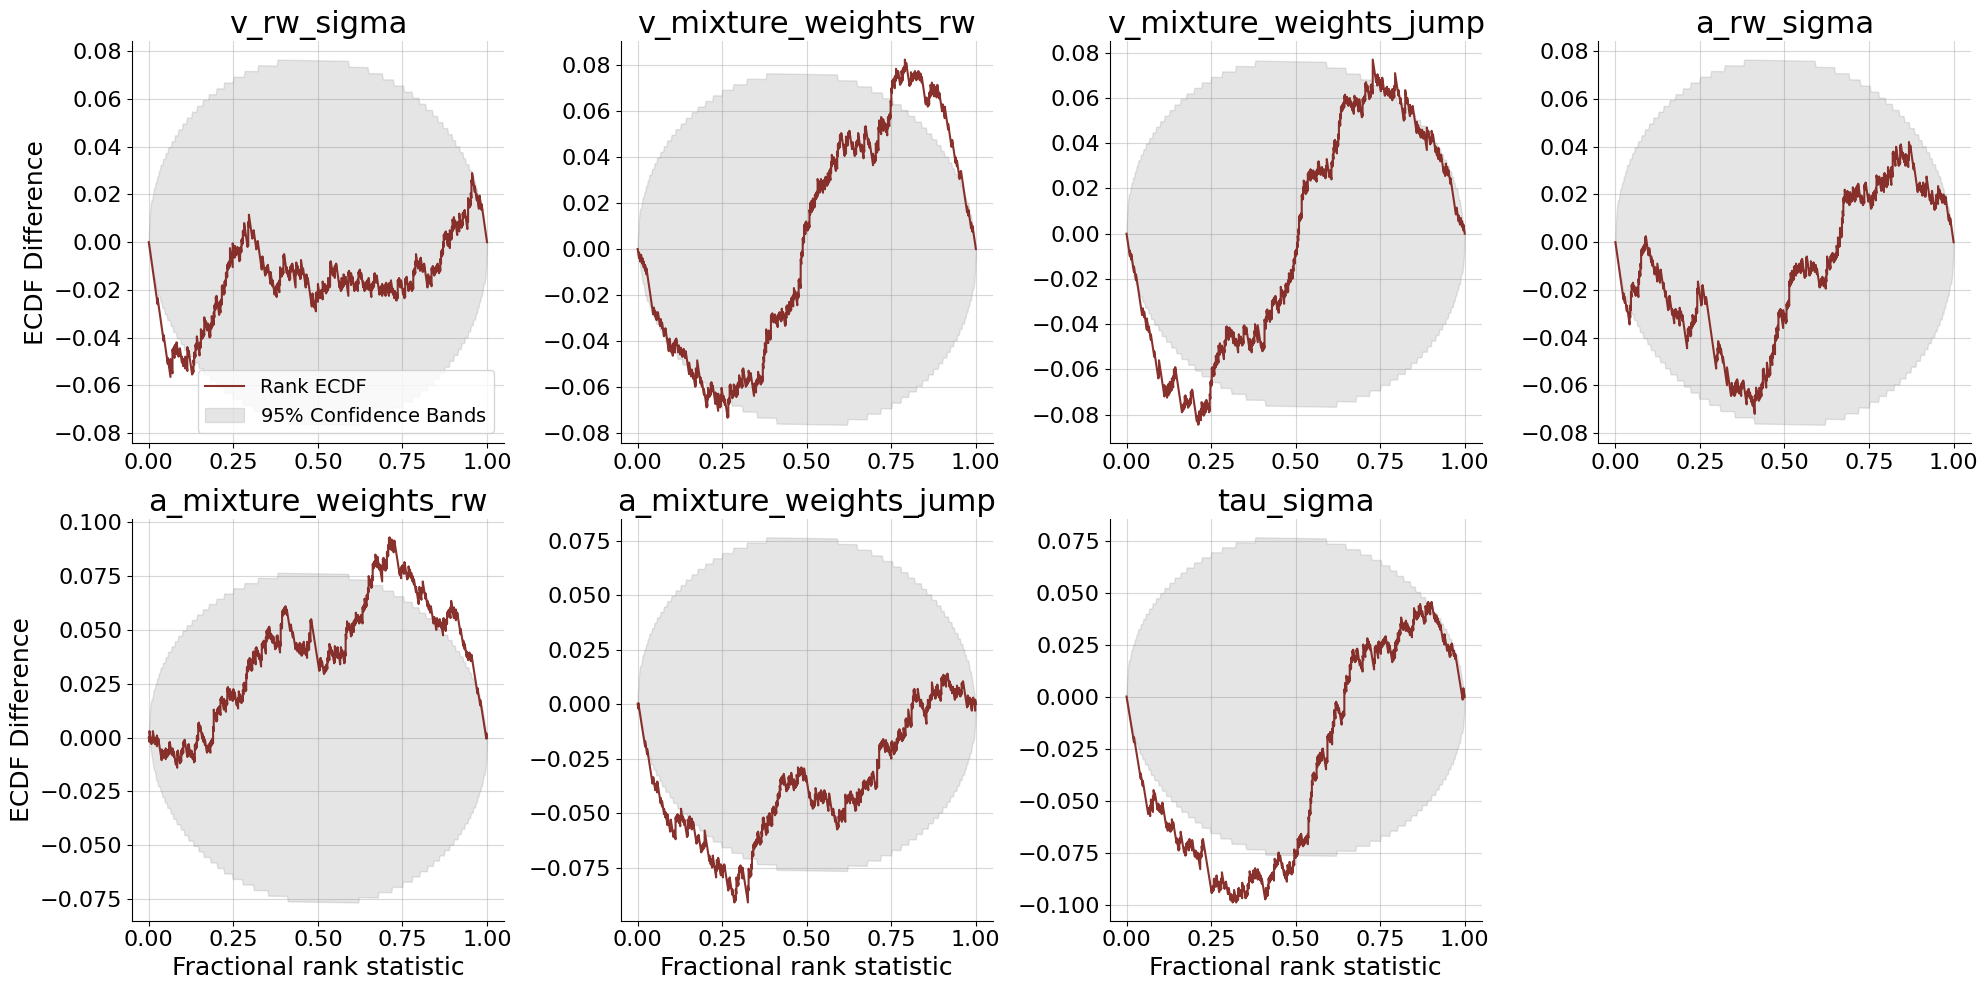

In [11]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    val_data,
    samples
)

## Data Fitting

In [12]:
data = pd.read_csv("data/data_color_discrimination.csv")